## cleaning the bank marketing dataset

In [9]:
## load in the whole dataset

import pandas as pd
from itables import show

df = pd.read_csv('../data/bank-full.csv', sep=';')

show(df)

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
## check the headers and make sure they are clean
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [ ]:
## check for all the ages

df['age'].dtype

dtype('int64')

In [14]:
## check if there is any customer with unkown contact

df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [15]:
### check if this unkown contacts agreed to subscribe
unknown_contact = df[df['contact'] == 'unknown']

print(unknown_contact['y'].value_counts())

y
no     12490
yes      530
Name: count, dtype: int64


In [17]:
## compare value of contacts by subscription

df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


In [19]:
## Answering the first question how many customers said yes to subscription and how many said no

subscription_count = df['y'].value_counts()
subscription_count

y
no     39922
yes     5289
Name: count, dtype: int64

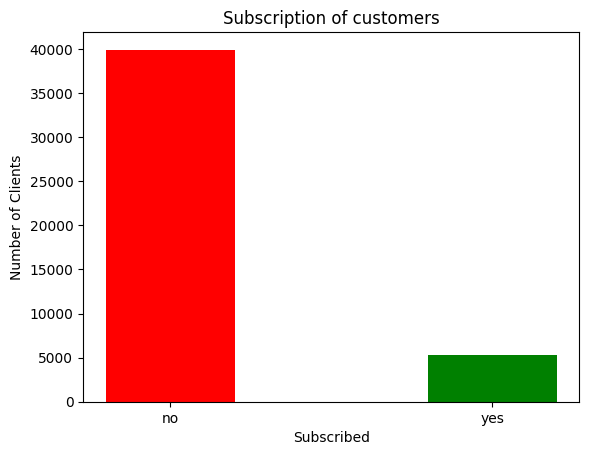

In [24]:
## show subscription in a bar graph

import matplotlib.pyplot as plt

plt.bar(['no','yes'], subscription_count.values, color=['red','green'], width=0.4)
plt.title('Subscription of customers')
plt.xlabel('Subscribed')
plt.ylabel('Number of Clients')
plt.show()

In [27]:
## find out the average age of customers being reached and if age play a role in whether someone subscribes

average_age = df['age'].mean()
min_age = df['age'].min()
oldest_age = df['age'].max()
median_age = df['age'].median()

print(f'average age is {average_age}')
print(f'Minimun age reached out to is {min_age}')
print(f'Oldest person reached out to is {oldest_age} years old')
print(f'Median age is {median_age}')

age_by_subscription = df.groupby('y')['age'].mean()
print(age_by_subscription)

average age is 40.93621021432837
Minimun age reached out to is 18
Oldest person reached out to is 95 years old
Median age is 39.0
y
no     40.838986
yes    41.670070
Name: age, dtype: float64


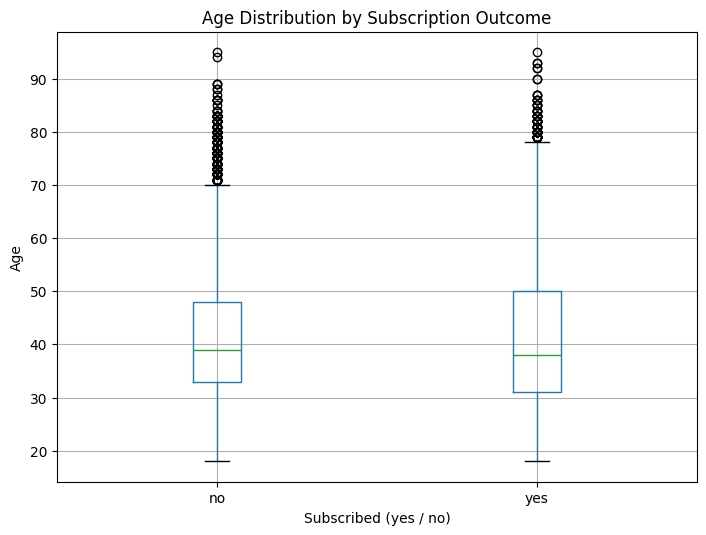

In [28]:
df.boxplot(column='age', by='y', figsize=(8, 6))

plt.title('Age Distribution by Subscription Outcome')
plt.suptitle('')
plt.xlabel('Subscribed (yes / no)')
plt.ylabel('Age')
plt.show()